<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml17_ann_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fashion MNIST 데이터셋 이미지 분류

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDClassifier

import tensorflow as tf
import keras

# Fashion MNIST 데이터셋

Keras에서 제공되는 데이터 셋.

10개 클래스(바지, 셔츠, 구두, ...)를 갖는 패션 아이템들이 28x28 크기의 흑백 이미지로 구성.

60,000개 훈련 셋/레이블, 10,000개 테스트 셋/레이블.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train.shape  # (n_samples, height, width)

(60000, 28, 28)

In [4]:
y_train.shape  # (n_samples,)

(60000,)

In [5]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [6]:
x_test.shape

(10000, 28, 28)

In [7]:
np.unique(y_test, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))

## 데이터셋 시각화

In [8]:
x_train[0]  #> 0 ~ 255 스케일

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

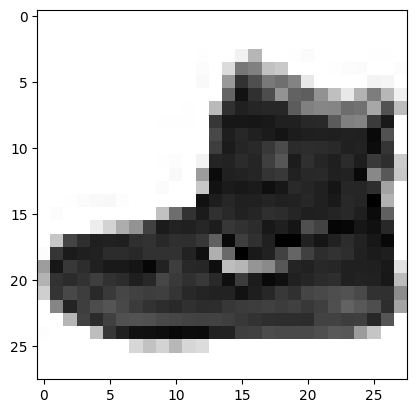

In [9]:
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.show()

In [10]:
def plot_fashion_mnist(arr, ncols=10):
    # arr: (n_samples, height, width) 모양의 3차원 배열
    # ncols: subplot의 컬럼 개수.
    n = len(arr)  # 출력할 이미지 개수
    nrows = int(np.ceil(n / ncols))  # subplot의 행 개수
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols, nrows))
    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j  # 배열 arr에서 선택할 이미지의 인덱스
            if nrows == 1 or ncols == 1:  # axes는 1차원 배열
                if idx < n:
                    axes[idx].imshow(arr[idx], cmap=plt.cm.binary)
                axes[idx].axis('off')
            else:  # axes는 2차원 배열
                if idx < n:
                    axes[i, j].imshow(arr[idx], cmap=plt.cm.binary)
                axes[i, j].axis('off')

    plt.show()

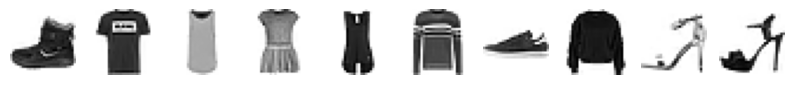

In [11]:
plot_fashion_mnist(x_train[:10])

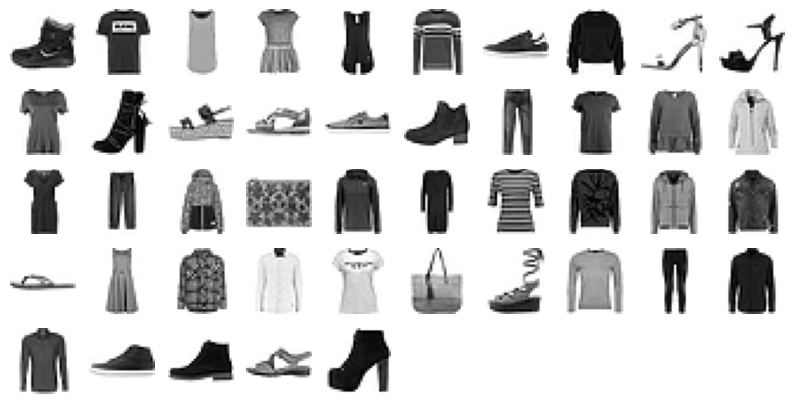

In [12]:
plot_fashion_mnist(x_train[:45])

## 데이터셋 스케일 변환

0 ~ 255 스케일을 0.0 ~ 1.0 스케일로 변환

In [13]:
x_train_scaled = x_train / 255.0

In [14]:
x_test_scaled = x_test / 255.0

## 데이터셋을 2D로 변환

In [15]:
x_train_scaled_2d = x_train_scaled.reshape((60_000, -1))
x_train_scaled_2d.shape

(60000, 784)

In [16]:
x_test_scaled_2d = x_test_scaled.reshape((10_000, -1))
x_test_scaled_2d.shape

(10000, 784)

# SGD vs 신경망 비교

## SGD Classifier

In [17]:
sgd = SGDClassifier(loss='log_loss', random_state=42, n_jobs=-1) # ML 모델 생성

In [18]:
sgd.fit(X=x_train_scaled_2d, y=y_train)  # ML 모델 훈련

SGDClassifier(loss='log_loss', n_jobs=-1, random_state=42)

In [19]:
sgd.coef_.shape  #> # of coefficients = 10 x 784 = 7840

(10, 784)

In [20]:
sgd.intercept_.shape  #> # of intercepts = 10

(10,)

In [21]:
# 각 샘플들이 각 클래스가 될 (10개의) 확률
tr_pred_prob = sgd.predict_proba(X=x_train_scaled_2d)

In [22]:
tr_pred_prob.shape

(60000, 10)

In [23]:
tr_pred_prob[:2]

array([[8.74080511e-08, 6.48920328e-07, 6.45596100e-06, 5.59408985e-08,
        7.28066534e-07, 1.03014953e-03, 6.89999756e-04, 3.91186355e-04,
        7.60894911e-05, 9.97804599e-01],
       [9.73703423e-01, 1.69634379e-07, 1.51596094e-02, 1.25355212e-04,
        2.59011068e-06, 2.93067357e-18, 1.09805704e-02, 1.39113613e-14,
        2.82821006e-05, 5.81504175e-10]])

In [24]:
# 예측한 레이블(클래스)
tr_pred = sgd.predict(X=x_train_scaled_2d)

In [25]:
tr_pred[:10]

array([9, 0, 3, 3, 3, 2, 7, 2, 5, 5], dtype=uint8)

In [26]:
y_train[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [27]:
# 훈련 셋 정확도
sgd.score(X=x_train_scaled_2d, y=y_train)

0.8621166666666666

In [28]:
# 테스트 셋 정확도
sgd.score(X=x_test_scaled_2d, y=y_test)

0.8363

## 출력층만 갖는 신경망

Sequential = Input + Dense

In [29]:
inputs = keras.layers.Input(shape=(784,))  # 입력층
dense = keras.layers.Dense(units=10, activation='softmax')  # 출력층
model = keras.Sequential(layers=[inputs, dense])  # 완전 연결 신경망

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# 신경망 모델 컴파일
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [32]:
# 신경망 모델 훈련
model.fit(x=x_train_scaled_2d, y=y_train, batch_size=64, epochs=10)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9621 - sparse_categorical_accuracy: 0.7035
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6707 - sparse_categorical_accuracy: 0.7867
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6063 - sparse_categorical_accuracy: 0.8055
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5714 - sparse_categorical_accuracy: 0.8140
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5482 - sparse_categorical_accuracy: 0.8205
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5316 - sparse_categorical_accuracy: 0.8246
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5185 - sparse_categorical_accuracy: 0.8278
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5086 - sparse_categorical_accuracy: 0.8316
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4998 - sparse_categorical_accuracy: 0.8328
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - 

In [33]:
# 신경망 모델이 훈련을 통해서 찾은 모델 파라미터들(가중치, weights)
model.weights

[<Variable path=sequential/dense/kernel, shape=(784, 10), dtype=float32, value=[[ 0.03549831  0.04500893  0.03557731 ...  0.08075447 -0.03319945
   -0.0347082 ]
  [ 0.07510693  0.04336465 -0.05264189 ... -0.03465393 -0.0431605
    0.04848322]
  [-0.04277151  0.08518723 -0.08584482 ...  0.02157378  0.0068622
   -0.02366845]
  ...
  [-0.07071347 -0.08701687  0.00461879 ...  0.00054376  0.04274466
    0.06122072]
  [-0.0834954   0.08576416  0.02567889 ... -0.00580255  0.02452269
   -0.06644703]
  [-0.02916489  0.0785218  -0.08505035 ...  0.04588084  0.06282018
    0.00506747]]>,
 <Variable path=sequential/dense/bias, shape=(10,), dtype=float32, value=[ 0.12399872 -0.11528851 -0.09449356  0.05662275 -0.5497546   1.2559624
   0.26915032 -0.09589915 -0.3016759  -0.54862493]>]

In [34]:
# 훈련 셋 평가
model.evaluate(x=x_train_scaled_2d, y=y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.4876 - sparse_categorical_accuracy: 0.8370


[0.4876039922237396, 0.8370166420936584]

In [35]:
# 테스트 셋 평가
model.evaluate(x=x_test_scaled_2d, y=y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5176 - sparse_categorical_accuracy: 0.8246


[0.517647922039032, 0.8245999813079834]

In [36]:
pred = model.predict(x=x_train_scaled_2d)
pred.shape

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


(60000, 10)

In [37]:
pred[:2]

array([[1.1453079e-06, 8.0905414e-07, 7.0890292e-06, 1.4436630e-06,
        1.5092200e-05, 1.3692595e-02, 1.3971441e-05, 4.6427948e-03,
        1.1472423e-03, 9.8047787e-01],
       [9.8194057e-01, 1.6642462e-05, 1.8297791e-03, 8.2199933e-04,
        5.4603488e-06, 9.8580051e-09, 1.5369013e-02, 4.8718192e-08,
        1.4019264e-05, 2.3991774e-06]], dtype=float32)

## 은닉층을 갖는 신경망

Sequential = Input + Dense(은닉층) + Dense(출력층)

*   은닉층: units=100, activation='sigmoid'
*   출력층: units=10, activation='softmax'

In [38]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(784,)))  # 입력층 추가
model.add(keras.layers.Dense(units=100, activation='sigmoid'))  # 은닉층(hidden layer) 추가
model.add(keras.layers.Dense(units=10, activation='softmax'))  # 출력층 추가

In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# 신경망 모델 컴파일
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [41]:
# 신경망 모델 훈련 - 손실함수를 최소화하는 모델 파라미터(가중치)들을 찾는 과정.
model.fit(x=x_train_scaled_2d, y=y_train, batch_size=64, epochs=10)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.6141 - sparse_categorical_accuracy: 0.6010
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.0245 - sparse_categorical_accuracy: 0.7312
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.8345 - sparse_categorical_accuracy: 0.7486
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7417 - sparse_categorical_accuracy: 0.7606
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.6857 - sparse_categorical_accuracy: 0.7721
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6468 - sparse_categorical_accuracy: 0.7822
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6174 - sparse_categorical_accuracy: 0.7890
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5942 - sparse_categorical_accuracy: 0.7971
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5750 - sparse_categorical_accuracy: 0.8034
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - 

In [42]:
model.weights[0].shape  # 은닉층 커널(kernel)

TensorShape([784, 100])

In [43]:
model.weights[1].shape  # 은닉층 바이어스(bias)

TensorShape([100])

In [44]:
model.weights[2].shape  # 출력층 커널(kernel)

TensorShape([100, 10])

In [45]:
model.weights[3].shape  # 출력층 바이어스(bias)

TensorShape([10])

In [46]:
# 훈련 셋 평가
model.evaluate(x=x_train_scaled_2d, y=y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5516 - sparse_categorical_accuracy: 0.8122


[0.5515790581703186, 0.812166690826416]

In [47]:
# 테스트 셋 평가
model.evaluate(x=x_test_scaled_2d, y=y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5726 - sparse_categorical_accuracy: 0.8004


[0.57257080078125, 0.8004000186920166]

# 활성화 함수(Activation Function)

*   활성화 함수: 신경망의 각 층(layer)에서 출력(output)을 내보내는 함수
*   은닉층(hidden layer)에서는 활성화 함수로 선형 함수를 사용하면 여러 개의 층을 연결하는 효과가 없음.
    *   단일 층을 사용하는 것과 같음.
    *   은닉층에서는 선형 함수를 활성화 함수로 사용하지 않음!
    *   은닉층에서는 비선형 함수만 활성화 함수로 사용해야 함.
*   출력층에서는 비선형 함수, 선형 함수 모두 활성화 함수로 사용할 수 있음.

## Sigmoid 함수

$\text{sigmoid}(x) = \dfrac{1}{1 + \exp(-x)}$

In [48]:
xvals = np.arange(-5, 5, 0.0001)

In [49]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [50]:
def plot_activation_fn(fn):
    # fn: 활성화 함수
    plt.figure(figsize=(8, 4))
    xvals = np.arange(-5, 5, 0.0001)
    yvals = fn(xvals)
    plt.plot(xvals, yvals)
    plt.grid()
    plt.show()

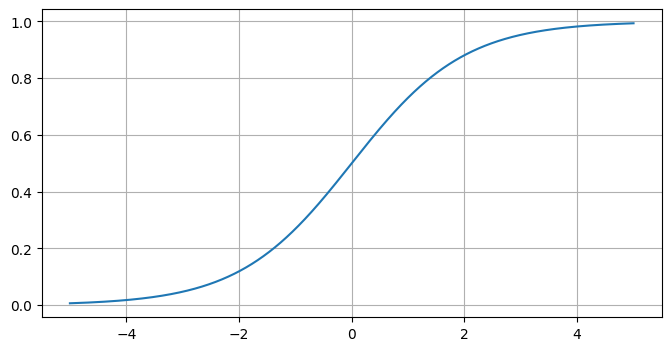

In [51]:
plot_activation_fn(sigmoid)

## Hyperbolic Tangent

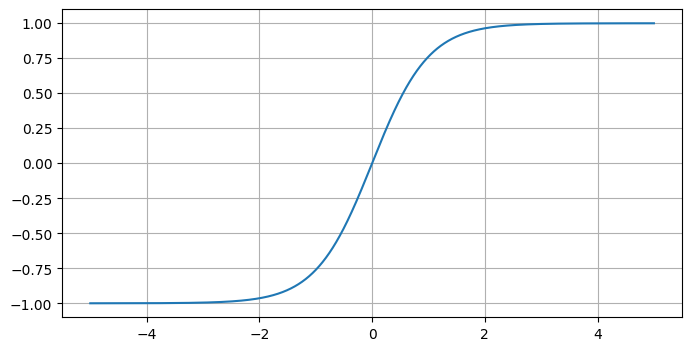

In [52]:
plot_activation_fn(np.tanh)

## ReLU(Rectified Linear Unit)

$
\text{ReLU}(x) =
    \begin{cases}
        x & \text{for } x \ge 0 \\
        0 & \text{for } x \lt 0
    \end{cases}
$

*   입력값이 양수이면 입력값 그대로 출력을 내보냄.
*   입력값이 음수이면 출력값으로 0으로 만듦.
*   이미지를 처리하는 신경망에서는 좋은 성능을 낸다고 알려져 있음.


In [53]:
def relu(x):
    return np.maximum(x, 0)

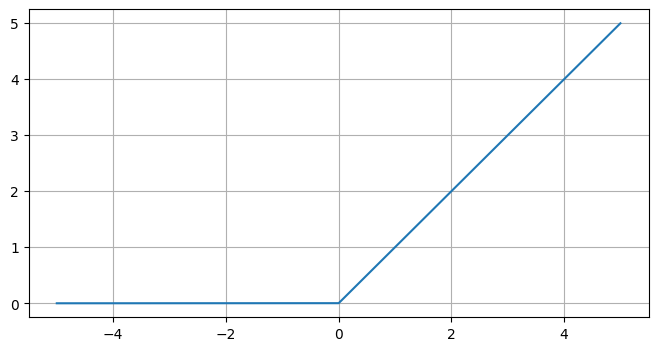

In [54]:
plot_activation_fn(relu)

## Leaky ReLU

$
\text{LeakyReLU}(x, \alpha) =
    \begin{cases}
        x & \text{for } x \ge 0 \\
        \alpha x & \text{for } x \lt 0, 0 \lt \alpha \lt 1
    \end{cases}
$

In [55]:
def leaky_relu(x, alpha=0.1):
    # 0 < alpha < 1
    return np.maximum(x, alpha * x)

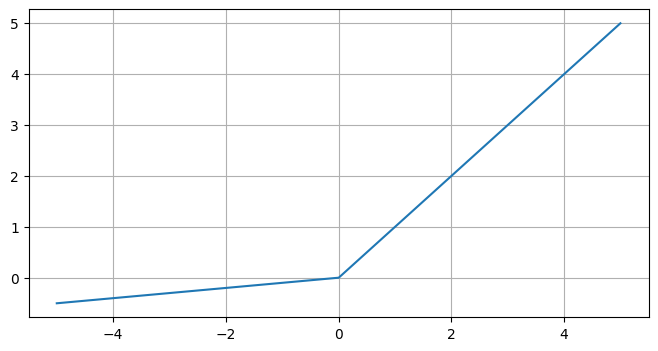

In [56]:
plot_activation_fn(leaky_relu)

## ELU(Exponential Linear Unit)

$
\text{ELU}(x, \alpha) =
    \begin{cases}
        x & \text{for } x \ge 0 \\
        \alpha (\exp(x) - 1) & \text{for } x \lt 0, \alpha \gt 0
    \end{cases}
$

In [57]:
def elu(x, alpha=1.0):
    # alpha > 0
    return np.where(x >= 0, x, alpha * (np.exp(x) - 1))

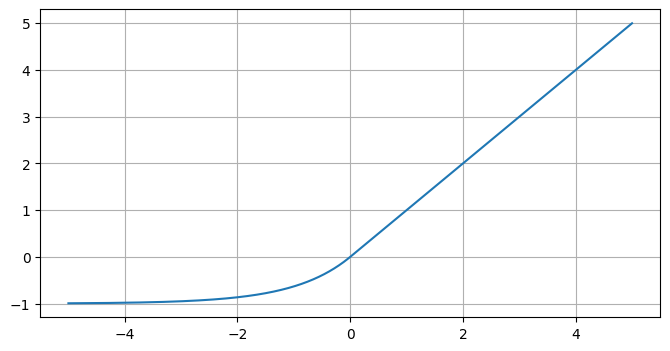

In [58]:
plot_activation_fn(elu)

*   출력층 활성화 함수
    *   이진 분류: sigmoid
    *   다중 클래스 분류: softmax
*   은닉층에서 활성화 함수 선택
    *   ELU > LeakyReLU > ReLU > tanh > sigmoid

## ELU를 활성화 함수로 사용하는 은닉층

Sequential = Input + Dense(은닉층) + Dense(출력층)

In [59]:
model = keras.Sequential()  # 완전 연결 신경망
model.add(keras.layers.Input(shape=(784,)))  # 입력층 추가
model.add(keras.layers.Dense(units=100, activation='elu'))  # 은닉층 추가
model.add(keras.layers.Dense(units=10, activation='softmax'))  # 출력층 추가

In [60]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [62]:
model.fit(x=x_train_scaled_2d, y=y_train, batch_size=64, epochs=10)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.8177 - sparse_categorical_accuracy: 0.7317
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5636 - sparse_categorical_accuracy: 0.8110
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5124 - sparse_categorical_accuracy: 0.8264
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4863 - sparse_categorical_accuracy: 0.8322
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4681 - sparse_categorical_accuracy: 0.8394
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4557 - sparse_categorical_accuracy: 0.8429
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4456 - sparse_categorical_accuracy: 0.8458
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.4372 - sparse_categorical_accuracy: 0.8489
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4303 - sparse_categorical_accuracy: 0.8508
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - 

In [63]:
# 훈련 셋 평가
model.evaluate(x=x_train_scaled_2d, y=y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.4244 - sparse_categorical_accuracy: 0.8522


[0.4243519902229309, 0.8521666526794434]

In [64]:
# 테스트 셋 평가
model.evaluate(x=x_test_scaled_2d, y=y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4625 - sparse_categorical_accuracy: 0.8332


[0.4625401496887207, 0.8331999778747559]

# Optimizer(최적화 함수)

**Optimizer(최적화 함수)**

*   손실함수를 최소화시키는 과정에서 모델 파라미터(가중치)들을 최적화하는 알고리즘.
*   경사하강법(Gradient Descent): 손실함수의 기울기가 줄어드는 방향으로 모델 파라미터들을 최적화시키는 알고리즘.

>> $w_{next} = w_{init} - \text{learning_rate} \cdot \text{gradient}$

*   아주 큰(깊은) 신경망인 경우는 모델 훈련에서 찾아야 하는 가중치들의 개수가 매우 많음.
*   모델 파라미터(가중치)들의 개수가 많을 수록 훈련 속도가 심각하게 느려질 수 있음.
*   훈련 속도를 빠르게 하는 방법:
    *   좋은 초기화 전략 사용하기
    *   좋은 활성화 함수 사용하기
    *   배치 정규화 사용하기
    *   사전 훈련된 네트워크(신경망)의 일부를 재사용
    *   일반적인 경사 하강법 대신 더 빠른 옵티마이저를 사용하기
*   **SGD**(Stochastic Gradient Descent, 확률적 경사 하강법)의 파라미터 변경 - SGD 변종 옵티마이저
    *   learning_rate(학습률) 파라미터를 변경
    *   momentum(모멘텀) 파라미터 값을 0보다 큰 값으로 변경 - **모멘텀 최적화(momentum optimization)**
    *   nesterov(네스테로프) 파라미터를 True로 변경 - **네스테로프 가속 경사(NAG, Nesterov Accelerated Gradient)**
*   적응형 학습률(adaptive learning rate)을 사용한 옵티마이저
    *   학습할 때마다 학습률을 변화시킴.
    *   **RMSprop**(Root Mean Squared Propagation): compile 메서드 optimzer 파라미터의 기본값.
        *   `learning_rate` 파라미터: 학습률.
        *   `rho`: 감쇠율(decay rate). 과거의 기울기 정보를 얼마나 유지할지를 설정.
        *   `momentum`: 모멘텀(관성, 가속도)를 주는 정도.
    *   **Adam**(Adaptive Mementum Estimation): 모멘텀 최적화 + RMSprop
    *   **Nadam**: Adam + Nesterov
    *   **AdaGrad**: 파라미터마다 학습률을 개별적으로 적응시키는 옵티마이저. 자주 업데이트되는 파라미터는 학습률을 줄이고, 드물게 학습되는 파라미터는 학습률을 높여 자주 등장하지 않는 피쳐의 가중치를 크게 업데이트하는 효과.

In [65]:
def create_model():
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(784,)))
    model.add(keras.layers.Dense(units=100, activation='elu'))
    model.add(keras.layers.Dense(units=10, activation='softmax'))

    return model

## RMSprop 옵티마이저

In [66]:
model_1 = create_model()

In [67]:
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model_1.compile(optimizer=keras.optimizers.RMSprop(),  # optimizer='rmsprop'
                loss=keras.losses.sparse_categorical_crossentropy,
                metrics=[keras.metrics.sparse_categorical_accuracy])

In [69]:
model_1.fit(x=x_train_scaled_2d, y=y_train, batch_size=64, epochs=10)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5358 - sparse_categorical_accuracy: 0.8098
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3985 - sparse_categorical_accuracy: 0.8547
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3599 - sparse_categorical_accuracy: 0.8696
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3346 - sparse_categorical_accuracy: 0.8781
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3182 - sparse_categorical_accuracy: 0.8829
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3038 - sparse_categorical_accuracy: 0.8889
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2911 - sparse_categorical_accuracy: 0.8936
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2817 - sparse_categorical_accuracy: 0.8965
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2734 - sparse_categorical_accuracy: 0.9000
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - 

In [70]:
model_1.evaluate(x=x_train_scaled_2d, y=y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2728 - sparse_categorical_accuracy: 0.8993


[0.27279603481292725, 0.8992833495140076]

In [71]:
model_1.evaluate(x=x_test_scaled_2d, y=y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3615 - sparse_categorical_accuracy: 0.8728


[0.36151066422462463, 0.8727999925613403]

## Adam 옵티마이저

In [72]:
model_2 = create_model()

In [73]:
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
model_2.compile(optimizer=keras.optimizers.Adam(),
                loss=keras.losses.sparse_categorical_crossentropy,
                metrics=[keras.metrics.sparse_categorical_accuracy])

In [75]:
model_2.fit(x=x_train_scaled_2d, y=y_train, batch_size=64, epochs=10)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.5216 - sparse_categorical_accuracy: 0.8169
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3962 - sparse_categorical_accuracy: 0.8596
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3587 - sparse_categorical_accuracy: 0.8699
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3327 - sparse_categorical_accuracy: 0.8791
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3145 - sparse_categorical_accuracy: 0.8840
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2973 - sparse_categorical_accuracy: 0.8905
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2857 - sparse_categorical_accuracy: 0.8939
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2737 - sparse_categorical_accuracy: 0.8997
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2625 - sparse_categorical_accuracy: 0.9010
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - 

In [76]:
model_2.evaluate(x=x_train_scaled_2d, y=y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2418 - sparse_categorical_accuracy: 0.9104


[0.2417844980955124, 0.9103666543960571]

In [77]:
model_2.evaluate(x=x_test_scaled_2d, y=y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3320 - sparse_categorical_accuracy: 0.8794


[0.332033634185791, 0.8794000148773193]

# `History` 객체

`History` 객체:

*   Model.fit() 메서드가 리턴하는 객체.
*   신경망 모델을 훈련(fit)시키는 과정(각각의 epoch)의 기록을 담고 있는 객체.


신경망 생성: Input(입력층) --> Dense(은닉층) --> Dense(출력층)

신경망 컴파일: RMSprop 옵티마이저를 사용.

신경망 훈련: epoch 20회.

훈련/테스트 셋에서의 정확도, 손실 그래프.

In [78]:
model = create_model()

In [79]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [81]:
result = model.fit(x=x_train_scaled_2d, y=y_train,
                   batch_size=64, epochs=20,
                   validation_data=[x_test_scaled_2d, y_test])

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.5381 - sparse_categorical_accuracy: 0.8091 - val_loss: 0.4945 - val_sparse_categorical_accuracy: 0.8208
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.3991 - sparse_categorical_accuracy: 0.8558 - val_loss: 0.4130 - val_sparse_categorical_accuracy: 0.8520
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3611 - sparse_categorical_accuracy: 0.8697 - val_loss: 0.4152 - val_sparse_categorical_accuracy: 0.8512
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.3373 - sparse_categorical_accuracy: 0.8762 - val_loss: 0.4633 - val_sparse_categorical_accuracy: 0.8352
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3217 - sparse_categorical_accuracy: 0.8820 - val_loss: 0.3873 - val_sparse_categorical_accuracy: 0.8618
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3070 - sparse_categorical_accuracy: 0.8860 - val_loss: 0.4089 - val_sparse_categorical_accuracy: 0.8486
Epoc

In [82]:
print(type(result))  #> History 클래스 타입

<class 'keras.src.callbacks.history.History'>


In [87]:
result.epoch

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [86]:
history = result.history  #> dict: 훈련셋과 검증셋의 손실, 정확도를 저장.
history

{'loss': [0.538104236125946,
  0.39907974004745483,
  0.3611370623111725,
  0.33734920620918274,
  0.32167574763298035,
  0.3069573640823364,
  0.293997198343277,
  0.2851563096046448,
  0.2741833031177521,
  0.266788125038147,
  0.25874826312065125,
  0.2529904842376709,
  0.24744442105293274,
  0.24083416163921356,
  0.2356581836938858,
  0.2300388514995575,
  0.2260827124118805,
  0.21977964043617249,
  0.21666203439235687,
  0.21307191252708435],
 'sparse_categorical_accuracy': [0.809149980545044,
  0.8557999730110168,
  0.8696833252906799,
  0.8761500120162964,
  0.8819500207901001,
  0.8859500288963318,
  0.8918833136558533,
  0.8946499824523926,
  0.899483323097229,
  0.9015499949455261,
  0.9040499925613403,
  0.9066500067710876,
  0.9088666439056396,
  0.9099666476249695,
  0.912766695022583,
  0.9157999753952026,
  0.916866660118103,
  0.9199000000953674,
  0.9197666645050049,
  0.9214666485786438],
 'val_loss': [0.4944802224636078,
  0.41303393244743347,
  0.4151501059532165

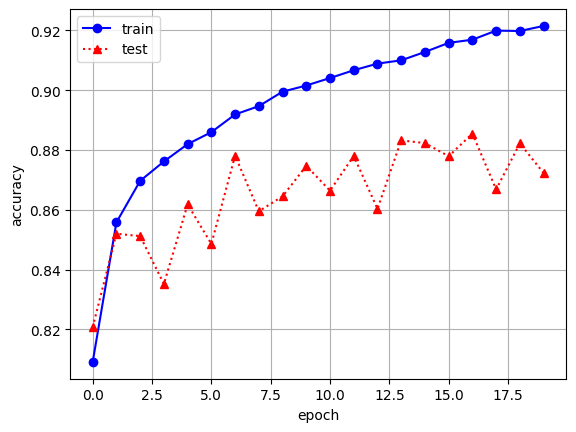

In [91]:
# epoch에 따른 (훈련/검증) 정확도 변화
plt.plot(result.epoch, history['sparse_categorical_accuracy'], 'bo-', label='train')
plt.plot(result.epoch, history['val_sparse_categorical_accuracy'], 'r^:', label='test')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid()
plt.show()

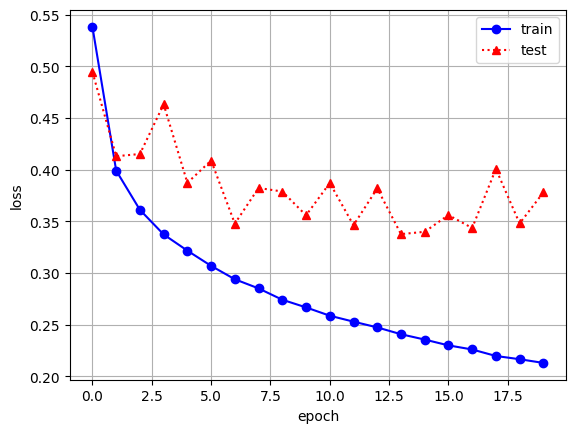

In [92]:
# epoch에 따른 (훈련/검증) 손실 변화
plt.plot(result.epoch, history['loss'], 'bo-', label='train')
plt.plot(result.epoch, history['val_loss'], 'r^:', label='test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid()
plt.show()

Adam optimizer를 사용해서 epoch 20번 실행하고, 훈련/테스트 셋에서의 정확도/손실 그래프를 시각화하세요.

In [93]:
keras.utils.set_random_seed(42)  # Python, NumPy, TensorFlow의 난수 시드를 고정.
model = create_model()
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])
result = model.fit(x=x_train_scaled_2d, y=y_train, batch_size=64, epochs=20,
                   validation_data=[x_test_scaled_2d, y_test])

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.5162 - sparse_categorical_accuracy: 0.8190 - val_loss: 0.4562 - val_sparse_categorical_accuracy: 0.8354
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3939 - sparse_categorical_accuracy: 0.8590 - val_loss: 0.4155 - val_sparse_categorical_accuracy: 0.8500
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.3586 - sparse_categorical_accuracy: 0.8703 - val_loss: 0.3951 - val_sparse_categorical_accuracy: 0.8567
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3342 - sparse_categorical_accuracy: 0.8789 - val_loss: 0.3799 - val_sparse_categorical_accuracy: 0.8635
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.3151 - sparse_categorical_accuracy: 0.8851 - val_loss: 0.3658 - val_sparse_categorical_accuracy: 0.8697
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.2994 - sparse_categorical_accuracy: 0.8902 - val_loss: 0.3553 - val_sparse_categorical_accuracy: 0.8735
Epoc

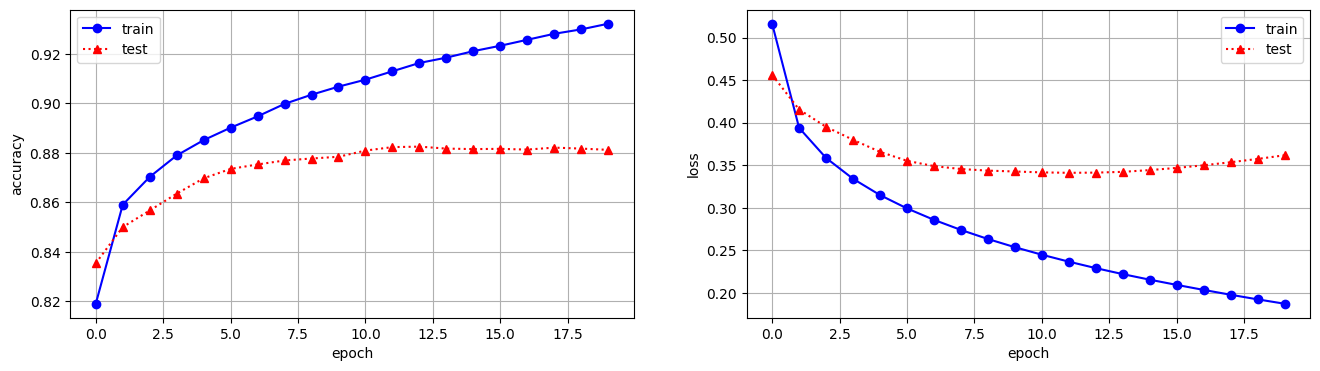

In [102]:
epochs = result.epoch  # list: 에포크 번호
history = result.history  # dict: 훈련/검증 손실/정확도 리스트

fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

axes[0].plot(epochs, history['sparse_categorical_accuracy'], 'bo-', label='train')
axes[0].plot(epochs, history['val_sparse_categorical_accuracy'], 'r^:', label='test')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend()
axes[0].grid()

axes[1].plot(epochs, history['loss'], 'bo-', label='train')
axes[1].plot(epochs, history['val_loss'], 'r^:', label='test')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend()
axes[1].grid()

plt.show()

# Dropout

*   신경망 모델의 과대적합(overfitting)을 줄이는 기법.
*   훈련 과정(epoch)에서 일부 유닛(unit)의 출력을 0으로 만드는 기법.
    *   다음 계층(layer)로 출력값을 전달하지 않음.
*   각 epoch마다 출력을 0으로 만드는 유닛은 무작위로 선택.
*   dropout의 비율만 설정.

In [103]:
keras.utils.set_random_seed(42)

model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28)))  # 입력층(input layer)
model.add(keras.layers.Flatten())  # flatten layer: (28, 28) --> (784,) 모양 변경
model.add(keras.layers.Dense(units=100, activation='elu'))  # 은닉층(hidden layer)
model.add(keras.layers.Dropout(rate=0.3))  # dropout layer: 은닉층의 출력들 중에서 무작위 30%를 0으로 만듦.
model.add(keras.layers.Dense(units=10, activation='softmax'))  # 출력층(output layer)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [105]:
result = model.fit(x=x_train_scaled, y=y_train, batch_size=64, epochs=20,
                   validation_data=[x_test_scaled, y_test])

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.5720 - sparse_categorical_accuracy: 0.7971 - val_loss: 0.4549 - val_sparse_categorical_accuracy: 0.8395
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.4434 - sparse_categorical_accuracy: 0.8399 - val_loss: 0.4237 - val_sparse_categorical_accuracy: 0.8479
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.4121 - sparse_categorical_accuracy: 0.8517 - val_loss: 0.4102 - val_sparse_categorical_accuracy: 0.8525
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.3904 - sparse_categorical_accuracy: 0.8589 - val_loss: 0.3938 - val_sparse_categorical_accuracy: 0.8576
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3742 - sparse_categorical_accuracy: 0.8634 - val_loss: 0.3836 - val_sparse_categorical_accuracy: 0.8605
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.3663 - sparse_categorical_accuracy: 0.8665 - val_loss: 0.3865 - val_sparse_categorical_accuracy: 0.8589
Epoc

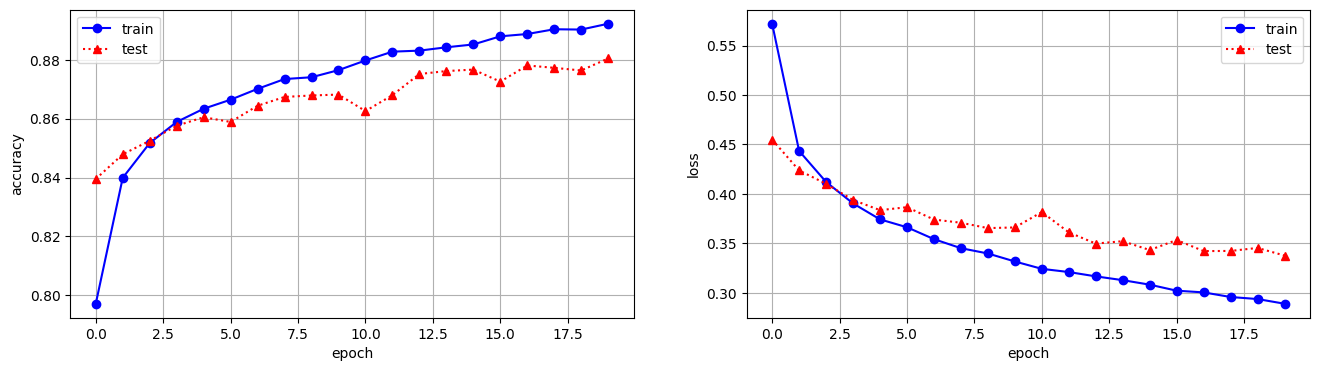

In [106]:
epochs = result.epoch
history = result.history

fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

axes[0].plot(epochs, history['sparse_categorical_accuracy'], 'bo-', label='train')
axes[0].plot(epochs, history['val_sparse_categorical_accuracy'], 'r^:', label='test')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend()
axes[0].grid()

axes[1].plot(epochs, history['loss'], 'bo-', label='train')
axes[1].plot(epochs, history['val_loss'], 'r^:', label='test')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend()
axes[1].grid()

plt.show()

# 모델 저장과 복원

In [107]:
model.weights

[<Variable path=sequential_7/dense_13/kernel, shape=(784, 100), dtype=float32, value=[[-0.26683196  0.36799896 -0.31834006 ... -0.32869315 -0.5455915
    0.22817978]
  [ 0.36836135  0.37813556  0.12716918 ... -0.20226982  0.30892855
   -0.12010346]
  [ 0.18482351  0.20387541 -0.49476072 ... -0.5105717   0.18820605
    0.4615401 ]
  ...
  [ 0.05230908  0.09570876 -0.11821119 ... -0.10439294 -0.4515194
    0.13711886]
  [-0.23142211 -0.1510433  -0.6973066  ...  0.09836685 -0.00971831
    0.38084984]
  [ 0.01641757  0.11796547 -0.78709656 ... -0.71404696 -0.16124
    0.45215264]]>,
 <Variable path=sequential_7/dense_13/bias, shape=(100,), dtype=float32, value=[ 0.61267656  0.48574224  0.40244046  0.08379089 -0.8126734  -0.24278069
  -0.1607918   0.1174188   0.34270093 -0.5075674   0.01184112  0.28027022
   0.25622386 -0.42004824  0.25264987 -0.24240161  0.4517962   0.379118
  -0.38063562 -0.5414674   0.6759716  -0.5722868   0.10449609  0.09067079
  -0.66350365  0.41745844  0.79865456  0.5

In [108]:
# 훈련 셋 평가(손실, 정확도 계산)
model.evaluate(x=x_train_scaled, y=y_train)  #> train acc. = 90.8%

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2460 - sparse_categorical_accuracy: 0.9081


[0.24596625566482544, 0.9081166386604309]

In [109]:
# 테스트 셋 평가(손실, 정확도 계산)
model.evaluate(x=x_test_scaled, y=y_test)  # test acc. = 88.0%

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3377 - sparse_categorical_accuracy: 0.8805


[0.3376663625240326, 0.8805000185966492]

## 모델 저장

In [110]:
# 모델 (파라미터)를 저장하기 위한 구글 드라이브 폴더 경로
path = '/content/drive/MyDrive/Colab Notebooks/lab_ml/'

# 모델 파라미터들만 저장하는 파일 - 파일 확장자는 '.weights.h5'로 설정
weights_file = path + 'model1.weights.h5'

# 모델 구조와 모델 파라미터들을 모두 저장하는 파일 - 파일 확장자는 '.keras'로 설정
model1_file = path + 'model1.keras'

In [111]:
# 모델 파라미터들(가중치, weights)만 저장
model.save_weights(weights_file)

In [112]:
# 모델 전체를 저장
model.save(model1_file)

## 모델 복원

### 가중치들만 저장한 파일(.weights.h5)에서 복원

*   모델 파라미터와 같은 구조의 모델을 먼저 생성
*   생성된 모델에서 `load_weights` 메서드를 호출 -> 모델 파라미터들을 복원
*   모델 **컴파일**
*   `predict`, `evaluate` 메서드를 사용해서 예측, 평가를 수행.

In [113]:
# 저장된 모델 파라미터들과 같은 구조의 신경망 모델을 생성
model_restore = keras.Sequential()
model_restore.add(keras.layers.Input(shape=(28, 28)))
model_restore.add(keras.layers.Flatten())
model_restore.add(keras.layers.Dense(units=100, activation='elu'))
model_restore.add(keras.layers.Dropout(rate=0.3))
model_restore.add(keras.layers.Dense(units=10, activation='softmax'))

In [114]:
# 신경망 모델에 모델 파라미터들을 복원
model_restore.load_weights(weights_file)

In [116]:
# model_restore.evaluate(x=x_train_scaled, y=y_train)
#> 복원된 모델은 컴파일되지 않은 상태이기 때문에 손실 함수, 평가 지표를 알 수가 없음.
#> evaluate가 에러가 발생

ValueError: You must call `compile()` before using the model.

In [118]:
# 복원된 모델 컴파일
model_restore.compile(optimizer=keras.optimizers.Adam(),
                      loss=keras.losses.sparse_categorical_crossentropy,
                      metrics=[keras.metrics.sparse_categorical_accuracy])

In [119]:
model_restore.evaluate(x=x_train_scaled, y=y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.2460 - sparse_categorical_accuracy: 0.9081


[0.24596625566482544, 0.9081166386604309]

In [120]:
model_restore.evaluate(x=x_test_scaled, y=y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3377 - sparse_categorical_accuracy: 0.8805


[0.3376663625240326, 0.8805000185966492]

### 모델 전체를 저장한 파일(.keras)에서 복원

확장자가 '.keras'인 파일에서 모델을 복원할 때는 컴파일까지 수행된 모델을 복원할 수 있음.

In [121]:
model_restore2 = keras.models.load_model(model1_file)

In [122]:
model_restore2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [123]:
model_restore2.evaluate(x=x_train_scaled, y=y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2460 - sparse_categorical_accuracy: 0.9081


[0.24596625566482544, 0.9081166386604309]